# Logistic regression: stable probabilities and matched objectives

**Objective.** Learn a binary decision rule with NumPy gradient descent and validate both
probabilities and labels against a reference model with the same L2 regularization.

## Reproducible setup

Install the package from the repository root with `python -m pip install -e ".[dev]"`,
then select a kernel from that environment. Run all cells from top to bottom.
The algorithm is imported from `ml_from_scratch`; this notebook contains only the experiment.
All data are bundled with scikit-learn or generated locally, with seed 42.

## Mathematical intuition

A linear score becomes a probability through
$$z_i=x_i^T w+b,\qquad p_i=\sigma(z_i)=\frac{1}{1+e^{-z_i}}.$$
With $\lambda=0.01$, the objective and gradient are
$$J=\frac1n\sum_i[\log(1+e^{z_i})-y_i z_i]+\frac{\lambda}{2}\|w\|^2,$$
$$\nabla_wJ=\frac1n X^T(p-y)+\lambda w,\qquad
\frac{\partial J}{\partial b}=\frac1n\sum_i(p_i-y_i).$$
The intercept is unpenalized. The package evaluates cross entropy from logits with
`logaddexp` and evaluates sigmoid by sign to avoid overflowing exponentials.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression as ReferenceLogisticRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.model_selection import train_test_split

from ml_from_scratch import LogisticRegression

SEED = 42

## Dataset and interpretation

Use all 30 breast cancer features. The split is stratified and scaling uses training
statistics only. The bundled encoding is 0 = malignant, 1 = benign. F1 therefore treats
benign as positive. This is an educational algorithm comparison, not clinical validation.

In [2]:
dataset = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    dataset.data,
    dataset.target,
    test_size=0.25,
    stratify=dataset.target,
    random_state=SEED,
)
mean, scale = X_train.mean(axis=0), X_train.std(axis=0)
scale = np.where(scale > 0, scale, 1.0)
X_train, X_test = (X_train - mean) / scale, (X_test - mean) / scale
print(f"Training samples: {len(y_train)}; test samples: {len(y_test)}")
print(dict(enumerate(dataset.target_names)))

Training samples: 426; test samples: 143
{0: np.str_('malignant'), 1: np.str_('benign')}


## Fit the implementation

`predict_proba` returns two columns in class order `[0, 1]`. `predict` applies the model's
configurable threshold (0.5 here). The stopping criterion is the Euclidean gradient norm,
and exhausting the update budget emits a convergence warning.

In [3]:
l2 = 0.01
model = LogisticRegression(learning_rate=0.25, max_iter=20_000, tol=1e-7, l2=l2)
model.fit(X_train, y_train)
probabilities = model.predict_proba(X_test)
print(f"Converged: {model.converged_}; updates: {model.n_iter_}")
print(
    f"Probability shape: {probabilities.shape}; "
    f"largest row-sum error: {np.max(np.abs(probabilities.sum(axis=1) - 1)):.2e}"
)

Converged: True; updates: 3851
Probability shape: (143, 2); largest row-sum error: 0.00e+00


## Reference comparison with the same penalty

For scikit-learn's convention, set $C=1/(n_{train}\lambda)$. Using an arbitrary default
would change the mathematical problem. L-BFGS and fixed-step GD are different optimizers,
so their iteration counts and tolerance values need not match.

In [4]:
reference = ReferenceLogisticRegression(
    C=1 / (len(y_train) * l2),
    solver="lbfgs",
    max_iter=20_000,
    tol=1e-10,
).fit(X_train, y_train)
for name, estimator in [("NumPy GD", model), ("scikit-learn", reference)]:
    prediction, probability = estimator.predict(X_test), estimator.predict_proba(X_test)
    print(
        f"{name:12s} accuracy={accuracy_score(y_test, prediction):.6f}  "
        f"F1={f1_score(y_test, prediction):.6f}  "
        f"log_loss={log_loss(y_test, probability):.6f}"
    )
print(
    "Maximum probability disagreement: "
    f"{np.max(np.abs(probabilities - reference.predict_proba(X_test))):.3e}"
)

NumPy GD     accuracy=0.986014  F1=0.988889  log_loss=0.085425
scikit-learn accuracy=0.986014  F1=0.988889  log_loss=0.085425
Maximum probability disagreement: 5.759e-07


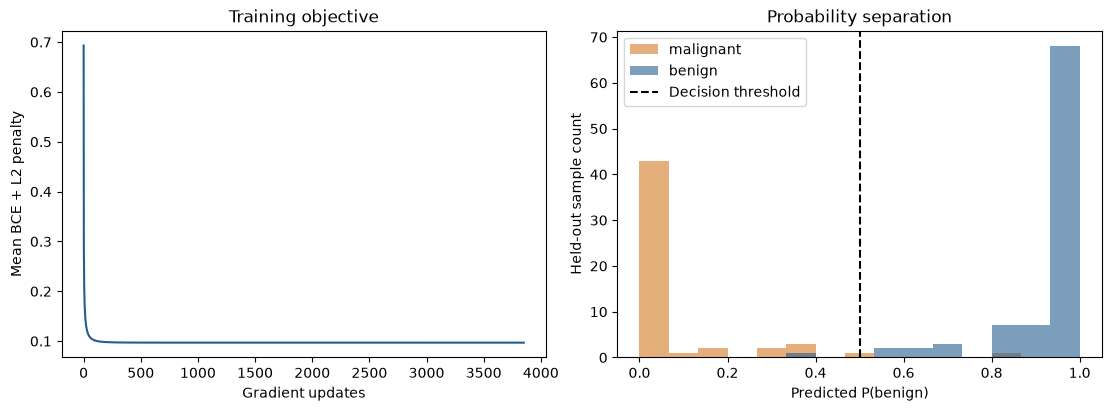

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
axes[0].plot(model.loss_history_, color="#245d91")
axes[0].set(xlabel="Gradient updates", ylabel="Mean BCE + L2 penalty", title="Training objective")
for label, color in [(0, "#d57a25"), (1, "#245d91")]:
    axes[1].hist(
        probabilities[y_test == label, 1],
        bins=np.linspace(0, 1, 16),
        alpha=0.6,
        color=color,
        label=dataset.target_names[label],
    )
axes[1].axvline(0.5, color="black", linestyle="--", label="Decision threshold")
axes[1].set(
    xlabel="Predicted P(benign)", ylabel="Held-out sample count", title="Probability separation"
)
axes[1].legend()
plt.show()

## Conclusion

Label agreement can hide small probability differences, so the reference check includes
log loss and the maximum probability gap. Explicit regularization matching makes the
comparison meaningful. Threshold changes trade precision for recall without refitting.

The repository's figure script also fits a separate two-feature model for a faithful
decision-boundary plot; that plot is not a projection of this 30-feature classifier.
Multiclass learning, probability calibration, and clinical use are outside this implementation's scope.
See [the numerical derivation](../docs/mathematics.md) and [benchmark methodology](../docs/benchmarking.md).